In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Parse the LAMMPS log file
data = []
with open('log.lammps', 'r') as f:
    reading_data = False
    for line in f:
        if 'Step' in line and 'Volume' in line:
            reading_data = True
            continue
        if reading_data:
            if line.startswith('Loop time'):
                break
            parts = line.split()
            if len(parts) == 7 and parts[0].isdigit():
                data.append([float(x) for x in parts])

# Create DataFrame
df = pd.DataFrame(data, columns=['Step', 'Volume', 'Press', 'Temp', 'PotEng', 'KinEng', 'TotEng'])

print(f"Loaded {len(df)} data points from box relaxation run")
df.head()

Loaded 1001 data points from box relaxation run


,Step,Volume,Press,Temp,PotEng,KinEng,TotEng
0,0.0,175.616,-64360.028,300.0,-36.292832,0.271446,-36.021386
1,10.0,175.616,-64360.028,300.0,-36.292832,0.271446,-36.021386
2,20.0,175.616,-64360.028,300.0,-36.292832,0.271446,-36.021386
3,30.0,175.616,-64360.028,300.0,-36.292832,0.271446,-36.021386
4,40.0,175.616,-64360.028,300.0,-36.292832,0.271446,-36.021386


In [11]:
# Parse minimization data
min_data = []
with open('log.lammps', 'r') as f:
    reading_min = False
    skip_next = False
    for line in f:
        if 'minimize' in line.lower():
            skip_next = True
            continue
        if skip_next and 'Step' in line and 'Volume' in line:
            reading_min = True
            skip_next = False
            continue
        if reading_min:
            if line.startswith('Loop time'):
                break
            parts = line.split()
            if len(parts) == 7 and parts[0].isdigit():
                min_data.append([float(x) for x in parts])

# Create DataFrame for minimization
df_min = pd.DataFrame(min_data, columns=['Step', 'Volume', 'Press', 'Temp', 'PotEng', 'KinEng', 'TotEng'])

print(f"Loaded {len(df_min)} data points from minimization run")
df_min.head()

Loaded 8 data points from minimization run


,Step,Volume,Press,Temp,PotEng,KinEng,TotEng
0,10000.0,175.61600,-64360.0280,300.0,-36.292832,0.271446,-36.021386
1,10010.0,170.40003,-43161.2000,300.0,-36.480172,0.271446,-36.208726
2,10020.0,165.28837,-18606.1590,300.0,-36.597023,0.271446,-36.325576
3,10030.0,161.27345,1745.8609,300.0,-36.733219,0.271446,-36.461773
4,10040.0,160.24594,2008.8330,300.0,-37.037664,0.271446,-36.766217


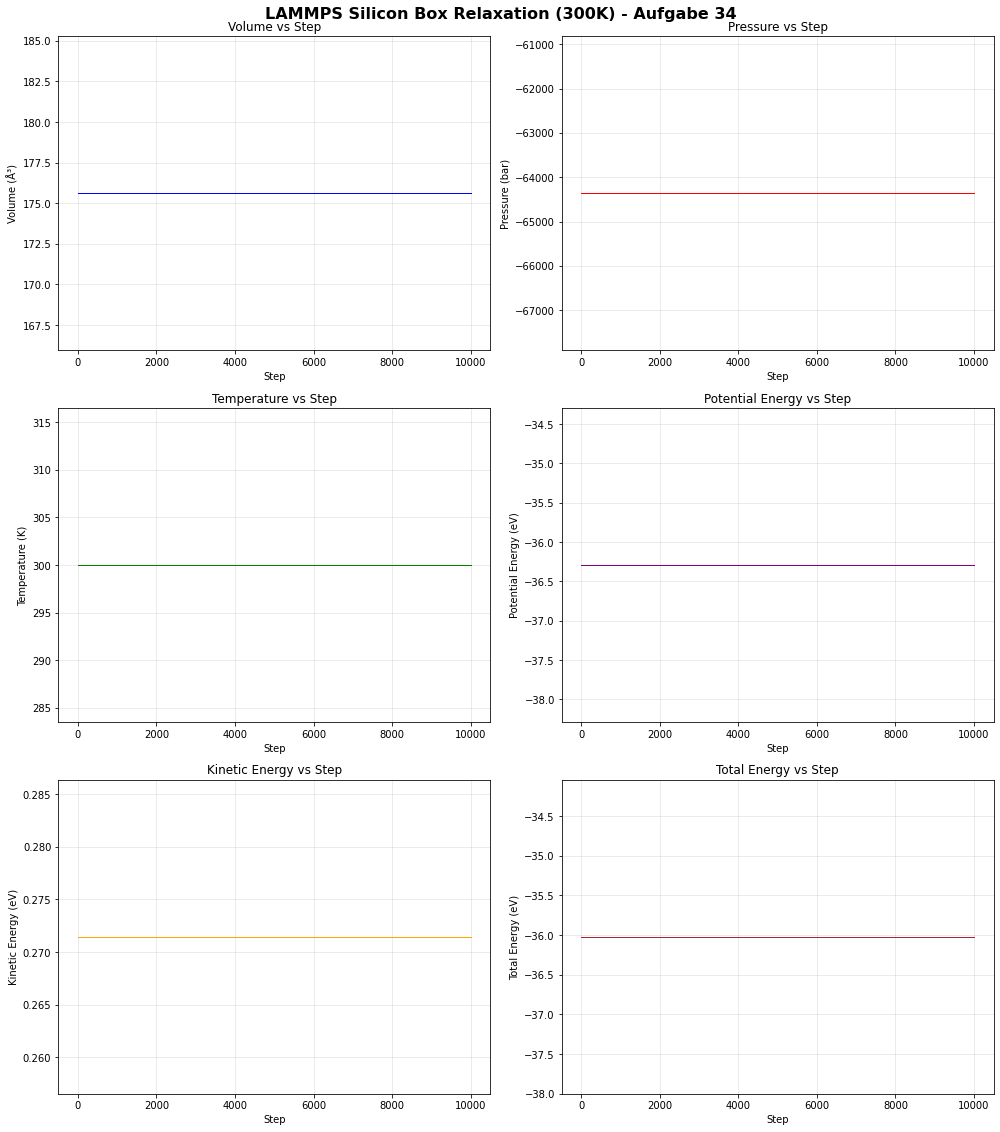

In [12]:
# Set up the plot style
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('LAMMPS Silicon Box Relaxation (300K) - Aufgabe 34', fontsize=16, fontweight='bold')

# Plot Volume
axes[0, 0].plot(df['Step'], df['Volume'], color='blue', linewidth=1)
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Volume (Å³)')
axes[0, 0].set_title('Volume vs Step')
axes[0, 0].grid(True, alpha=0.3)

# Plot Pressure
axes[0, 1].plot(df['Step'], df['Press'], color='red', linewidth=1)
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Pressure (bar)')
axes[0, 1].set_title('Pressure vs Step')
axes[0, 1].grid(True, alpha=0.3)

# Plot Temperature
axes[1, 0].plot(df['Step'], df['Temp'], color='green', linewidth=1)
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Temperature (K)')
axes[1, 0].set_title('Temperature vs Step')
axes[1, 0].grid(True, alpha=0.3)

# Plot Potential Energy
axes[1, 1].plot(df['Step'], df['PotEng'], color='purple', linewidth=1)
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Potential Energy (eV)')
axes[1, 1].set_title('Potential Energy vs Step')
axes[1, 1].grid(True, alpha=0.3)

# Plot Kinetic Energy
axes[2, 0].plot(df['Step'], df['KinEng'], color='orange', linewidth=1)
axes[2, 0].set_xlabel('Step')
axes[2, 0].set_ylabel('Kinetic Energy (eV)')
axes[2, 0].set_title('Kinetic Energy vs Step')
axes[2, 0].grid(True, alpha=0.3)

# Plot Total Energy
axes[2, 1].plot(df['Step'], df['TotEng'], color='brown', linewidth=1)
axes[2, 1].set_xlabel('Step')
axes[2, 1].set_ylabel('Total Energy (eV)')
axes[2, 1].set_title('Total Energy vs Step')
axes[2, 1].grid(True, alpha=0.3)
y_min = df['TotEng'].min()
y_max = df['TotEng'].max()
y_range = y_max - y_min
if y_range > 0:
    axes[2, 1].set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)
axes[2, 1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

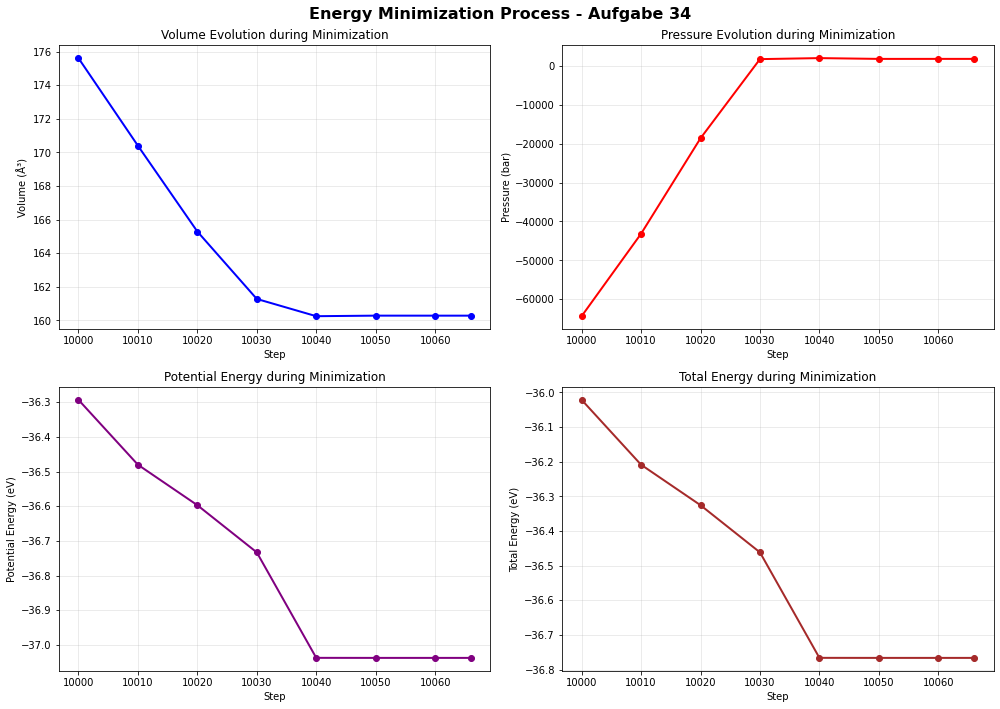

In [13]:
# Plot minimization process
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Energy Minimization Process - Aufgabe 34', fontsize=16, fontweight='bold')

# Volume during minimization
axes[0, 0].plot(df_min['Step'], df_min['Volume'], color='blue', linewidth=2, marker='o')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Volume (Å³)')
axes[0, 0].set_title('Volume Evolution during Minimization')
axes[0, 0].grid(True, alpha=0.3)

# Pressure during minimization
axes[0, 1].plot(df_min['Step'], df_min['Press'], color='red', linewidth=2, marker='o')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Pressure (bar)')
axes[0, 1].set_title('Pressure Evolution during Minimization')
axes[0, 1].grid(True, alpha=0.3)

# Potential Energy during minimization
axes[1, 0].plot(df_min['Step'], df_min['PotEng'], color='purple', linewidth=2, marker='o')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Potential Energy (eV)')
axes[1, 0].set_title('Potential Energy during Minimization')
axes[1, 0].grid(True, alpha=0.3)

# Total Energy during minimization
axes[1, 1].plot(df_min['Step'], df_min['TotEng'], color='brown', linewidth=2, marker='o')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Total Energy (eV)')
axes[1, 1].set_title('Total Energy during Minimization')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

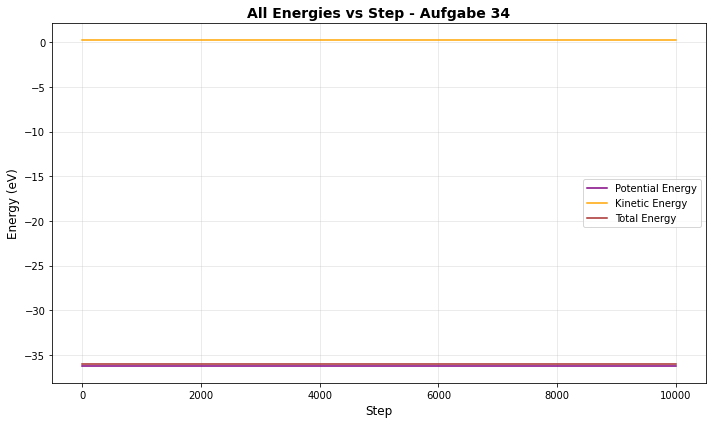

In [14]:
# Combined energy plot
plt.figure(figsize=(10, 6))
plt.plot(df['Step'], df['PotEng'], label='Potential Energy', color='purple', linewidth=1.5)
plt.plot(df['Step'], df['KinEng'], label='Kinetic Energy', color='orange', linewidth=1.5)
plt.plot(df['Step'], df['TotEng'], label='Total Energy', color='brown', linewidth=1.5)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Energy (eV)', fontsize=12)
plt.title('All Energies vs Step - Aufgabe 34', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Print statistics for box relaxation
print("\nBox Relaxation Statistics (300K):")
print("="*50)
print(f"Volume: {df['Volume'].mean():.3f} ± {df['Volume'].std():.3f} Å³")
print(f"Pressure: {df['Press'].mean():.1f} ± {df['Press'].std():.1f} bar")
print(f"Temperature: {df['Temp'].mean():.2f} ± {df['Temp'].std():.2f} K")
print(f"\nTotal System Energies:")
print(f"Potential Energy: {df['PotEng'].mean():.5f} ± {df['PotEng'].std():.5f} eV")
print(f"Kinetic Energy: {df['KinEng'].mean():.5f} ± {df['KinEng'].std():.5f} eV")
print(f"Total Energy: {df['TotEng'].mean():.5f} ± {df['TotEng'].std():.5f} eV")


Box Relaxation Statistics (300K):
Volume: 175.616 ± 0.000 Å³
Pressure: -64360.0 ± 0.0 bar
Temperature: 300.00 ± 0.00 K

Total System Energies:
Potential Energy: -36.29283 ± 0.00000 eV
Kinetic Energy: 0.27145 ± 0.00000 eV
Total Energy: -36.02139 ± 0.00000 eV


In [16]:
# Print equilibrium values after minimization
print("\n" + "="*60)
print("EQUILIBRIUM STATE AFTER MINIMIZATION (Aufgabe 34)")
print("="*60)
final_volume = df_min.iloc[-1]['Volume']
final_pressure = df_min.iloc[-1]['Press']
final_pot_energy = df_min.iloc[-1]['PotEng']
final_kin_energy = df_min.iloc[-1]['KinEng']
final_tot_energy = df_min.iloc[-1]['TotEng']
final_temp = df_min.iloc[-1]['Temp']

print(f"\nEquilibrium Volume:     {final_volume:.6f} Å³")
print(f"Equilibrium Pressure:   {final_pressure:.6f} bar")
print(f"Final Temperature:      {final_temp:.2f} K")
print(f"\nEquilibrium Energies:")
print(f"Potential Energy:       {final_pot_energy:.6f} eV")
print(f"Kinetic Energy:         {final_kin_energy:.6f} eV")
print(f"Total Energy:           {final_tot_energy:.6f} eV")
print(f"\nEnergy per atom:        {final_pot_energy/8:.6f} eV/atom")
print("="*60)


EQUILIBRIUM STATE AFTER MINIMIZATION (Aufgabe 34)

Equilibrium Volume:     160.278120 Å³
Equilibrium Pressure:   1808.959300 bar
Final Temperature:      300.00 K

Equilibrium Energies:
Potential Energy:       -37.037804 eV
Kinetic Energy:         0.271446 eV
Total Energy:           -36.766358 eV

Energy per atom:        -4.629726 eV/atom


In [17]:
# Mean and Standard Deviation for all quantities
print("Mean and Standard Deviation for all quantities:")
print("="*60)
print(f"Step:              Mean = {df['Step'].mean():.2f},   Std = {df['Step'].std():.2f}")
print(f"Volume (Å³):       Mean = {df['Volume'].mean():.3f}, Std = {df['Volume'].std():.3f}")
print(f"Pressure (bar):    Mean = {df['Press'].mean():.2f},  Std = {df['Press'].std():.2f}")
print(f"Temperature (K):   Mean = {df['Temp'].mean():.2f},   Std = {df['Temp'].std():.2f}")
print(f"Potential Eng (eV): Mean = {df['PotEng'].mean():.6f}, Std = {df['PotEng'].std():.6f}")
print(f"Kinetic Eng (eV):  Mean = {df['KinEng'].mean():.6f}, Std = {df['KinEng'].std():.6f}")
print(f"Total Eng (eV):    Mean = {df['TotEng'].mean():.6f}, Std = {df['TotEng'].std():.6f}")

Mean and Standard Deviation for all quantities:
Step:              Mean = 5000.00,   Std = 2891.08
Volume (Å³):       Mean = 175.616, Std = 0.000
Pressure (bar):    Mean = -64360.03,  Std = 0.00
Temperature (K):   Mean = 300.00,   Std = 0.00
Potential Eng (eV): Mean = -36.292832, Std = 0.000000
Kinetic Eng (eV):  Mean = 0.271446, Std = 0.000000
Total Eng (eV):    Mean = -36.021386, Std = 0.000000


## Temperature vs Kinetic Energy Analysis

C:\Users\da1qu1r1\AppData\Local\Temp\ipykernel_25924\1639678842.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(df["KinEng"], df["Temp"], 1)


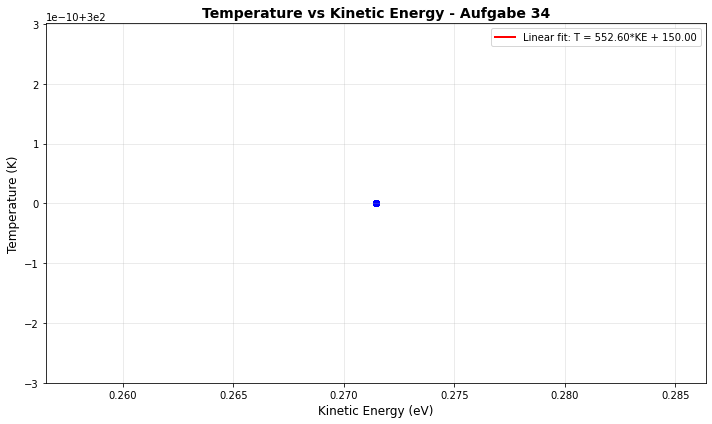

Linear relationship: Temperature = 552.60 * Kinetic Energy + 150.00


In [18]:
# Plot Temperature as a function of Kinetic Energy
plt.figure(figsize=(10, 6))
plt.scatter(df["KinEng"], df["Temp"], alpha=0.6, s=30, color='blue')
plt.xlabel('Kinetic Energy (eV)', fontsize=12)
plt.ylabel('Temperature (K)', fontsize=12)
plt.title('Temperature vs Kinetic Energy - Aufgabe 34', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Fit a linear regression line
coefficients = np.polyfit(df["KinEng"], df["Temp"], 1)
poly_line = np.poly1d(coefficients)
plt.plot(df["KinEng"], poly_line(df["KinEng"]), color='red', linewidth=2, label=f'Linear fit: T = {coefficients[0]:.2f}*KE + {coefficients[1]:.2f}')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Linear relationship: Temperature = {coefficients[0]:.2f} * Kinetic Energy + {coefficients[1]:.2f}")

In [19]:
# Verify the theoretical slope with proper units
# Equipartition theorem: KE = (f/2) * k_B * T
# Rearranging: T = (2 / (f * k_B)) * KE

n_atoms = 8
degrees_of_freedom = 3 * n_atoms  # 3 DOF per atom in 3D
k_B_eV_per_K = 8.617333e-5  # Boltzmann constant in eV/K

# Theoretical slope: T/KE = 2 / (f * k_B)
theoretical_slope = 2 / (degrees_of_freedom * k_B_eV_per_K)

print("Theoretical Analysis:")
print("="*60)
print(f"Number of atoms: {n_atoms}")
print(f"Degrees of freedom (3N): {degrees_of_freedom}")
print(f"Boltzmann constant: {k_B_eV_per_K} eV/K")
print(f"\nTheoretical slope (T/KE): {theoretical_slope:.2f} K/eV")
print(f"Fitted slope from data: {coefficients[0]:.2f} K/eV")
print(f"Difference: {abs(theoretical_slope - coefficients[0]):.2f} K/eV ({100*abs(theoretical_slope - coefficients[0])/theoretical_slope:.1f}%)")

# Check if LAMMPS removes COM motion (would give f = 21 instead of 24)
theoretical_slope_no_com = 2 / ((degrees_of_freedom - 3) * k_B_eV_per_K)
print(f"\nIf COM motion removed (f=21): {theoretical_slope_no_com:.2f} K/eV")
print(f"Difference from fit: {abs(theoretical_slope_no_com - coefficients[0]):.2f} K/eV ({100*abs(theoretical_slope_no_com - coefficients[0])/theoretical_slope_no_com:.1f}%)")

Theoretical Analysis:
Number of atoms: 8
Degrees of freedom (3N): 24
Boltzmann constant: 8.617333e-05 eV/K

Theoretical slope (T/KE): 967.04 K/eV
Fitted slope from data: 552.60 K/eV
Difference: 414.45 K/eV (42.9%)

If COM motion removed (f=21): 1105.19 K/eV
Difference from fit: 552.60 K/eV (50.0%)
